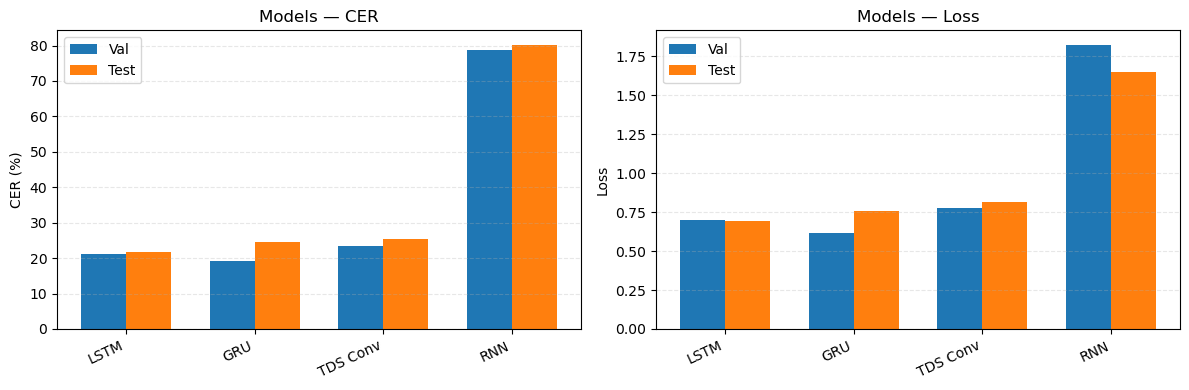

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv('architecture_model_results.csv')

def plot_model_group(models, title_prefix, label_map=None):
    """Plot CER and Loss subplots with val (blue) and test (orange) bars."""
    plot_df = df[df['model'].isin(models)].copy()
    if plot_df.empty:
        print(f'No data for: {models}')
        return
    plot_df = plot_df.set_index('model').loc[models].sort_values('test_CER', ascending=True).reset_index()
    models = plot_df['model'].tolist()
    plot_df = plot_df.set_index('model')
    labels = [label_map.get(m, m.replace('recurrent_', '').replace('_ctc', '')) for m in models]

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    x = range(len(labels))
    w = 0.35

    # CER
    val_cer = plot_df['val_CER'].values
    test_cer = plot_df['test_CER'].values
    axes[0].bar([i - w/2 for i in x], val_cer, w, label='Val', color='C0')
    axes[0].bar([i + w/2 for i in x], test_cer, w, label='Test', color='C1')
    axes[0].set_title(f'{title_prefix} — CER')
    axes[0].set_ylabel('CER (%)')
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(labels, rotation=25, ha='right')
    axes[0].legend()
    axes[0].grid(axis='y', linestyle='--', alpha=0.3)

    # Loss
    val_loss = plot_df['val_loss'].values
    test_loss = plot_df['test_loss'].values
    axes[1].bar([i - w/2 for i in x], val_loss, w, label='Val', color='C0')
    axes[1].bar([i + w/2 for i in x], test_loss, w, label='Test', color='C1')
    axes[1].set_title(f'{title_prefix} — Loss')
    axes[1].set_ylabel('Loss')
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(labels, rotation=25, ha='right')
    axes[1].legend()
    axes[1].grid(axis='y', linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.show()

INITIAL = ['recurrent_lstm_ctc', 'tds_conv_ctc', 'recurrent_rnn_ctc', 'recurrent_gru_ctc']
plot_model_group(INITIAL, 'Models', {
    'recurrent_lstm_ctc': 'LSTM', 'recurrent_gru_ctc': 'GRU',
    'tds_conv_ctc': 'TDS Conv', 'recurrent_rnn_ctc': 'RNN'
})

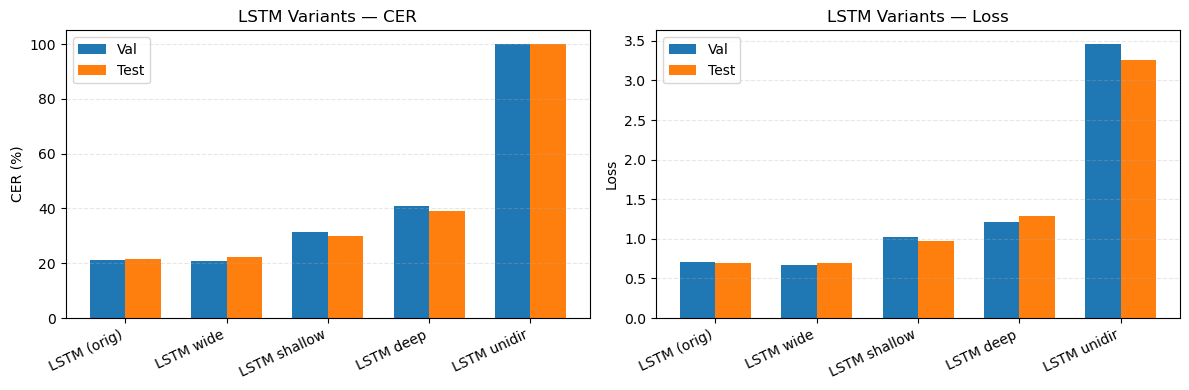

In [ ]:
models = ['recurrent_lstm_ctc', 'recurrent_lstm_ctc_wide', 'recurrent_lstm_ctc_shallow', 'recurrent_lstm_ctc_deep', 'recurrent_lstm_ctc_unidirectional']
plot_model_group(models, 'LSTM Variants', dict(zip(models, ['LSTM (orig)', 'LSTM wide', 'LSTM shallow', 'LSTM deep', 'LSTM unidir'])))

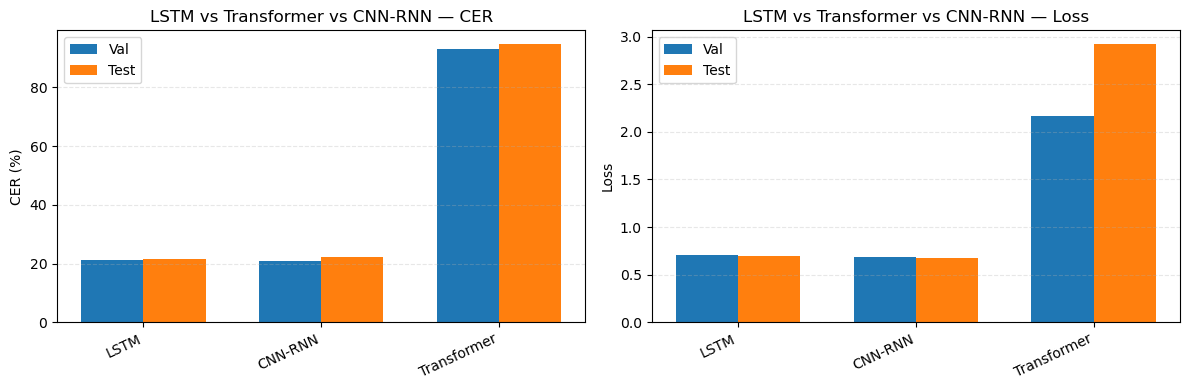

In [ ]:
THREE_ARCH = ['recurrent_lstm_ctc', 'transformer_ctc', 'cnn_rnn_ctc']
plot_model_group(THREE_ARCH, 'LSTM vs Transformer vs CNN-RNN', {
    'recurrent_lstm_ctc': 'LSTM',
    'cnn_rnn_ctc': 'CNN-RNN',
    'transformer_ctc': 'Transformer',
})